### Deep learning clasification model

In [145]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
from sklearn.metrics import classification_report, r2_score, jaccard_score, confusion_matrix, cohen_kappa_score
import seaborn as sns

In [146]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2023-12-31")

fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp="SQA")
fishing = fishing_ds["CPUE_class"]
fishing = fishing.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

fishing, effort, mask = xr.align(fishing, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)

In [147]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, so, mixed, zo, temp_bottom,  
        ugo, vgo, chl, cdm, pp,
        month_sin, month_cos,
        # lat, lon,
        # depth,
        ]

vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)

split_year = 2020

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(m_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)

(132, 12, 62, 24)
(132, 30, 16)
(132, 30, 16)
      feature       VIF
9          PP  9.911651
7         CHL  7.497059
4        to_b  6.619519
0          to  6.454134
3          zo  6.451228
1          so  6.181937
10  month_sin  3.958323
11  month_cos  3.427458
5         vgo  3.337311
6         ugo  2.994825
2      mlotst  2.718146
8         CDM  2.485041
torch.Size([72, 12, 12, 62, 24])
torch.Size([72, 30, 16])
torch.Size([72, 30, 16])


In [148]:
# -------- UNet 3D blocks--------

# -------- Basic Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            nn.Dropout3d(0.15),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            )

    def forward(self, x):
        return self.block(x)


# -------- Decoder Block --------
class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, (1, 2, 2), stride=(1, 2, 2))
        self.conv_block = ConvBlock(out_channels + skip_channels, out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches
        x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)

        x = self.conv_block(x)
        return x

# -------- Temporal Aggregation Block --------
class TemporalAggregationBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid()
        )
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2) 
        feat = (feat * weights).sum(dim=2)    
        return feat

class GlobalAttentionBranch(nn.Module):
    def __init__(self, channels, time_pooling=None):
        super().__init__()
        reduction = max(channels // 4, 8)
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool3d((time_pooling, 1, 1)),
            nn.Conv3d(channels, reduction, 1),
            nn.GELU(),
            nn.Conv3d(reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.branch(x)

class TemporalMixBlock(nn.Module):
    def __init__(self, channels, window_size=5):
        super().__init__()
        
        # Enforce odd window size to ensure symmetric padding across time
        if window_size % 2 == 0:
            raise ValueError(f"window_size must be odd (3, 5, 7), got {window_size}")
        pad_t = window_size // 2

        self.mix = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=(window_size, 1, 1), padding=(pad_t, 0, 0)),
            nn.BatchNorm3d(channels),
            nn.GELU()
        )

    def forward(self, x):
        return x + self.mix(x)

In [149]:
# -------- U-Net 3D temporal collapse after bottleneck --------
class UNet3D_2(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1, 2, 2))

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d((1, 2, 2)) # (1, 2, 2) for no temporal downsampling

        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4)
        self.temp_mix = TemporalMixBlock(base_ch * 4, window_size=7)
        self.global_att = GlobalAttentionBranch(base_ch * 4)
        
        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch * 4, base_ch * 2, base_ch * 2)
        self.decoder1 = DecoderBlock3D(base_ch * 2, base_ch, base_ch)
    
        # -------- Temporal Aggregation --------
        self.temporal_agg = TemporalAggregationBlock(base_ch)

        # -------- Classifier Head --------
        self.classifier = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.GELU(),
            nn.Conv2d(base_ch, 3, 1)  
        )

    def forward(self, x, mask=None):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        b = self.temp_mix(b)     
        b = b * self.global_att(b)

        # -------- Decoder --------
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # -------- Temporal Aggregation --------
        final_2d = self.temporal_agg(d1)
        
        # -------- Classifier Head --------
        logits = self.classifier(final_2d)
        
        # interpolate to output shape      
        logits = F.interpolate(logits, size=self.out_hw, mode="bilinear", align_corners=False)

        if mask is not None:
            # Match out shape: (B, 1, H, W)
            logits = logits * mask.unsqueeze(1).float()
        return logits

In [150]:
def ce_ssim_loss(
    logits,
    targets,
    mask,          
    weights=None,
    ssim_weight=0.2,
    window_size=11 
):
    # Ensure mask is float for multiplication
    mask = mask.float()
    
    # -------------------------
    # 1. Cross entropy (Masked)
    # -------------------------
    # Use reduction='none' to get the per-pixel loss: shape (B, H, W)
    ce_unreduced = F.cross_entropy(
        logits,
        targets.long(),
        weight=weights,
        reduction="none" 
    )
    
    # Multiply by mask and take the mean over valid pixels only
    valid_pixels = mask.sum() + 1e-8 # Add epsilon to avoid division by zero
    ce = (ce_unreduced * mask).sum() / valid_pixels

    # -------------------------
    # 2. Convert to probabilities
    # -------------------------
    probs = F.softmax(logits, dim=1)

    # One-hot targets
    num_classes = logits.shape[1]

    target_onehot = F.one_hot(
        targets.long(),
        num_classes=num_classes
    ).permute(0, 3, 1, 2).float()

    # -------------------------
    # 3. SSIM (Masked)
    # -------------------------
    pad = window_size // 2

    mu_p = F.avg_pool2d(probs, window_size, 1, pad)
    mu_t = F.avg_pool2d(target_onehot, window_size, 1, pad)

    sigma_p = F.avg_pool2d(probs**2, window_size, 1, pad) - mu_p**2
    sigma_t = F.avg_pool2d(target_onehot**2, window_size, 1, pad) - mu_t**2
    sigma_pt = (
        F.avg_pool2d(probs * target_onehot, window_size, 1, pad)
        - mu_p * mu_t
    )

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = (
        (2 * mu_p * mu_t + C1) *
        (2 * sigma_pt + C2)
    ) / (
        (mu_p**2 + mu_t**2 + C1) *
        (sigma_p + sigma_t + C2)
    )
    
    # ssim_map is (B, C, H, W), mask is (B, H, W)
    # Expand mask to (B, 1, H, W) so it broadcasts across classes
    mask_expanded = mask.unsqueeze(1)
    
    # Apply mask and compute mean over valid regions
    ssim_map_masked = ssim_map * mask_expanded
    valid_pixels_ssim = mask_expanded.sum() * num_classes + 1e-8
    ssim_loss = 1.0 - (ssim_map_masked.sum() / valid_pixels_ssim)

    # -------------------------
    # 4. Final loss
    # -------------------------
    return ce + ssim_weight * ssim_loss

In [153]:
class CESpatialLoss(nn.Module):
    def __init__(self, window_size=11): 
        super().__init__()
        self.window_size = window_size
        
        # Create a uniform 2D window for spatial context tracking
        self.register_buffer(
            "window", 
            torch.ones(1, 1, window_size, window_size) / (window_size ** 2)
        )

    def forward(self, pred, target, mask, weights=None, ssim_weight=0.5):
        """
        pred:    (B, C, H, W) - Raw logits from the model (e.g., C=3 classes)
        target:  (B, H, W)    - Class labels (automatically converted to Long)
        mask:    (B, H, W)    - Binary mask (1 for valid, 0 for ignore)
        weights: (C,)         - Optional class weights for Cross Entropy
        """
        # FIX: Explicitly cast target to Long to prevent the RuntimeError
        target = target.long()
        mask_float = mask.float()
        
        # 1. Masked Cross-Entropy Loss
        ce_loss = F.cross_entropy(pred, target, weight=weights, reduction='none')
        masked_ce = (ce_loss * mask_float).sum() / (mask_float.sum() + 1e-8)
        
        # 2. Fully Differentiable Masked SSIM (on Probabilities)
        ssim_loss = self._differentiable_ssim(pred, target, mask_float)
        
        return masked_ce + (ssim_weight * ssim_loss)

    def _differentiable_ssim(self, pred, target, mask):
        B, C, H, W = pred.shape
        
        # Convert logits to probabilities
        probs = F.softmax(pred, dim=1)
        
        # Convert targets to one-hot encoding (B, C, H, W)
        target_oh = F.one_hot(target, num_classes=C).permute(0, 3, 1, 2).float()
        
        # Reshape to treat each class channel as an independent grayscale image for SSIM
        probs = probs.reshape(B * C, 1, H, W)
        target_oh = target_oh.reshape(B * C, 1, H, W)
        
        # Expand the mask to match the C channels
        mask_expanded = mask.unsqueeze(1).repeat(1, C, 1, 1).reshape(B * C, 1, H, W)
        
        # Probabilities and one-hot vectors always have a data range of exactly [0, 1]
        data_range = 1.0 
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2

        pad = self.window_size // 2

        # Calculate means
        mu1 = F.conv2d(probs, self.window, padding=pad)[:, :, :H, :W]
        mu2 = F.conv2d(target_oh, self.window, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        # Calculate variances
        sigma1_sq = F.conv2d(probs * probs, self.window, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.conv2d(target_oh * target_oh, self.window, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.conv2d(probs * target_oh, self.window, padding=pad)[:, :, :H, :W] - mu1_mu2

        # SSIM map calculation
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Apply mask to SSIM map safely
        masked_ssim = (ssim_map * mask_expanded).sum() / (mask_expanded.sum() + 1e-8)
        
        # Minimize loss -> return 1 - SSIM
        return 1.0 - masked_ssim

1/500 | Loss: 1.614 | Train F1: 0.118 | Val F1: 0.219 | F1_1: 0.000 | F1_2: 0.219 | p1: 0.000 r1: 0.000 | p2: 0.123 r2: 1.000
2/500 | Loss: 1.566 | Train F1: 0.081 | Val F1: 0.000 | F1_1: 0.000 | F1_2: 0.000 | p1: 0.000 r1: 0.000 | p2: 0.000 r2: 0.000
3/500 | Loss: 1.542 | Train F1: 0.088 | Val F1: 0.000 | F1_1: 0.000 | F1_2: 0.000 | p1: 0.000 r1: 0.000 | p2: 0.000 r2: 0.000
4/500 | Loss: 1.513 | Train F1: 0.087 | Val F1: 0.000 | F1_1: 0.000 | F1_2: 0.000 | p1: 0.000 r1: 0.000 | p2: 0.000 r2: 0.000
5/500 | Loss: 1.493 | Train F1: 0.109 | Val F1: 0.000 | F1_1: 0.000 | F1_2: 0.000 | p1: 0.000 r1: 0.000 | p2: 0.000 r2: 0.000
6/500 | Loss: 1.475 | Train F1: 0.130 | Val F1: 0.000 | F1_1: 0.000 | F1_2: 0.000 | p1: 0.000 r1: 0.000 | p2: 0.000 r2: 0.000
7/500 | Loss: 1.453 | Train F1: 0.216 | Val F1: 0.000 | F1_1: 0.000 | F1_2: 0.000 | p1: 0.000 r1: 0.000 | p2: 0.000 r2: 0.000
8/500 | Loss: 1.433 | Train F1: 0.252 | Val F1: 0.004 | F1_1: 0.000 | F1_2: 0.004 | p1: 0.000 r1: 0.000 | p2: 0.053 r2

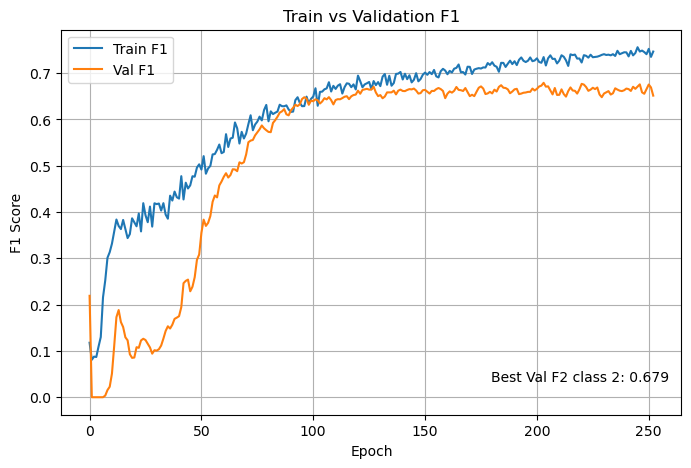

In [154]:
def compute_metrics_multiclass(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),

        # Class 1
        "precision_1": precision_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),
        "recall_1": recall_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),
        "f1_1": f1_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),

        # Class 2
        "precision_2": precision_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
        "recall_2": recall_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
        "f1_2": f1_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
    }


best_model_path = "./modelos/modelo_class.pth"
out_hw = y_train.shape[1:]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet3D_2(in_channels=in_channels, out_hw=out_hw).to(device)

ce_ssim_loss = CESpatialLoss(window_size=11).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
weights = torch.tensor([1.0, 1.0, 1.0]).to(device)

best_val_f1 = -float("inf")
patience = 50
counter = 0
epochs = 500

train_f1_history = []
val_f1_history = []

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()

    train_preds = []
    train_trues = []
    total_loss = 0

    # Unpack x, y, and mask (m)
    for x, y, m in train_loader:

        x = x.to(device)
        y = y.to(device)  # (B,H,W)
        m = m.to(device)  # (B,H,W)

        optimizer.zero_grad()

        logits = model(x)  # (B,3,H,W)

        # Pass the mask to the updated loss function
        loss = ce_ssim_loss(logits, y, mask=m, weights=weights, ssim_weight=0.5)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.softmax(logits, dim=1).argmax(dim=1)

        # Filter predictions and targets using the mask
        # Converting mask to boolean creates a 1D tensor of only the valid pixels
        m_bool = m.bool()
        
        valid_preds = preds[m_bool]
        valid_trues = y[m_bool]

        train_preds.append(valid_preds.detach().cpu().numpy())
        train_trues.append(valid_trues.detach().cpu().numpy())

    y_true = np.concatenate(train_trues)
    y_pred = np.concatenate(train_preds)

    train_metrics = compute_metrics_multiclass(y_true, y_pred)
    train_f1 = (train_metrics["f1_1"] + train_metrics["f1_2"]) / 2

    # ---------------- VALIDATION ----------------
    model.eval()

    val_preds = []
    val_trues = []

    with torch.no_grad():
        # Unpack x, y, and mask (m)
        for x, y, m in test_loader:

            x = x.to(device)
            y = y.to(device)
            m = m.to(device)
            m_bool = m.bool()

            logits = model(x)

            preds = torch.softmax(logits, dim=1).argmax(dim=1)
            
            valid_preds = preds[m_bool]
            valid_trues = y[m_bool]

            val_preds.append(valid_preds.cpu().numpy())
            val_trues.append(valid_trues.cpu().numpy())

    y_true_val = np.concatenate(val_trues)
    y_pred_val = np.concatenate(val_preds)

    val_metrics = compute_metrics_multiclass(y_true_val, y_pred_val)

    # val_f1 = (val_metrics["f1_1"] + val_metrics["f1_2"]) / 2  # Focus on both classes
    val_f1 = val_metrics["f1_2"]  # Focus on class 2 for early stopping

    # ---------------- EARLY STOPPING ----------------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    print(
        f"{epoch+1}/{epochs} | "
        f"Loss: {total_loss/len(train_loader):.3f} | "
        f"Train F1: {train_f1:.3f} | "
        f"Val F1: {val_f1:.3f} | "
        f"F1_1: {val_metrics['f1_1']:.3f} | "
        f"F1_2: {val_metrics['f1_2']:.3f} | "
        f"p1: {val_metrics['precision_1']:.3f} r1: {val_metrics['recall_1']:.3f} | "
        f"p2: {val_metrics['precision_2']:.3f} r2: {val_metrics['recall_2']:.3f}"
    )

    train_f1_history.append(train_f1)
    val_f1_history.append(val_f1)
    

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_f1_history, label="Train F1")
plt.plot(val_f1_history, label="Val F1")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1")
plt.annotate(f"Best Val F2 class 2: {best_val_f1:.3f}", xy=(0.98, 0.08), xycoords='axes fraction', ha='right', va='bottom')
plt.legend()
plt.grid(True)

plt.show()


In [155]:
# 1. Load weights and set to evaluation mode
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

all_preds = []
all_targets = []
all_masks = []  

# 2. Gather predictions across the entire test set
with torch.no_grad():
    for x, y, m in test_loader:
        x = x.to(device)
        
        logits = model(x)
        # Get the predicted class index (B, H, W)
        pred = logits.argmax(dim=1)    
        
        # Keep them as 2D batches and move to CPU
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.numpy())
        all_masks.append(m.numpy())


preds_all = np.concatenate(all_preds, axis=0).astype(float)
targets_all = np.concatenate(all_targets, axis=0).astype(float)
masks_all = np.concatenate(all_masks, axis=0)

preds_all[masks_all == 0] = np.nan
targets_all[masks_all == 0] = np.nan


In [ ]:
def compute_metrics(preds, targets):

    # =====================================================
    # 1. Classification & Segmentation Metrics (Filtered)
    # =====================================================
    valid_idx = ~np.isnan(targets) & ~np.isnan(preds)
    y_true_flat = targets[valid_idx].astype(int)
    y_pred_flat = preds[valid_idx].astype(int)
    
    print("=== Classification Report ===")
    report = classification_report(y_true_flat, y_pred_flat, labels=[0, 1, 2], zero_division=0)
    print(report)
    
    iou_per_class = jaccard_score(y_true_flat, y_pred_flat, average=None, labels=[0, 1, 2])
    kappa = cohen_kappa_score(y_true_flat, y_pred_flat)
    
    print("=== Spatial Segmentation Metrics ===")
    print(f"IoU Class 0 (Nothing):       {iou_per_class[0]:.3f}")
    print(f"IoU Class 1 (Low CPUE):      {iou_per_class[1]:.3f}")
    print(f"IoU Class 2 (High CPUE):     {iou_per_class[2]:.3f}")
    print(f"Cohen's Kappa Score:         {kappa:.3f}\n")
    
    # New Plot: Confusion Matrix
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['None (0)', 'Low CPUE (1)', 'High CPUE (2)'],
                yticklabels=['None (0)', 'Low CPUE (1)', 'High CPUE (2)'])
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.title('Confusion Matrix')
    plt.show()
    
    # =====================================================
    # 2. PLOTTING: Spatial Means
    # =====================================================

    y_pred_mean = np.nanmean(preds, axis=0)
    y_true_mean = np.nanmean(targets, axis=0)
    y_true_mean = np.where(np.isnan(y_true_mean), 0, y_true_mean)
    y_pred_mean = np.where(np.isnan(y_pred_mean), 0, y_pred_mean)

    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis')
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    
    vmax = np.nanmax(np.abs(error)) if not np.isnan(error).all() else 1.0
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm(vcenter=0.0, halfrange=vmax))
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # 3. PLOTTING: Time Series Comparison
    # =====================================================

    y_pred_plot2 = np.nansum(preds, axis=(1, 2))
    y_true_plot2 = np.nansum(targets, axis=(1, 2))
    y_true_plot2 = np.where(np.isnan(y_true_plot2), 0, y_true_plot2)
    y_pred_plot2 = np.where(np.isnan(y_pred_plot2), 0, y_pred_plot2)
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_plot2, label="True")
    plt.plot(y_pred_plot2, label="Predicted")
    plt.annotate(f"R2: {r2_plot2:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
    plt.xlabel("Time (Months)")
    plt.title("Time Series Comparison")
    plt.grid()
    plt.legend()
    plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      2453
           1       0.74      0.70      0.72      1462
           2       0.66      0.70      0.68       549

    accuracy                           0.77      4464
   macro avg       0.74      0.74      0.74      4464
weighted avg       0.77      0.77      0.77      4464

=== Spatial Segmentation Metrics ===
IoU Class 0 (Nothing):       0.699
IoU Class 1 (Low CPUE):      0.562
IoU Class 2 (High CPUE):     0.514
Cohen's Kappa Score:         0.603



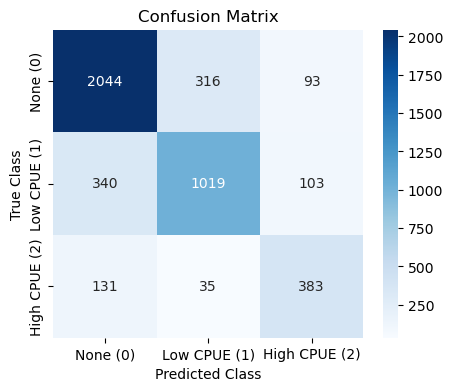

C:\Users\rubar\AppData\Local\Temp\ipykernel_28660\175791982.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_28660\175791982.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


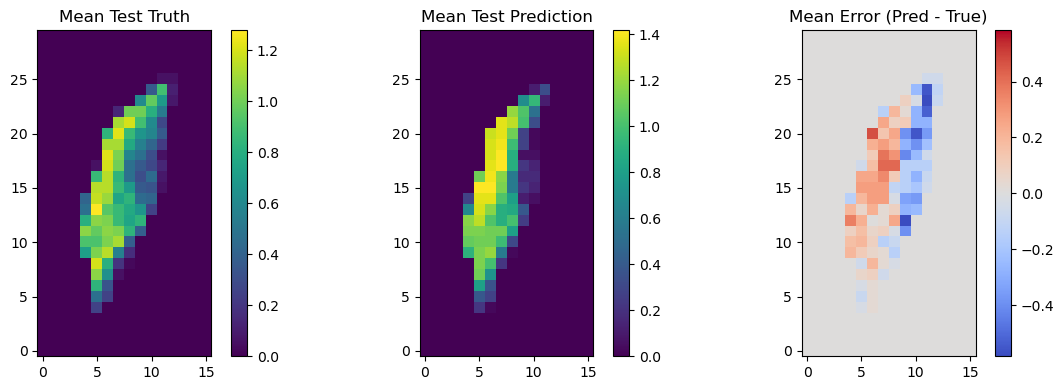

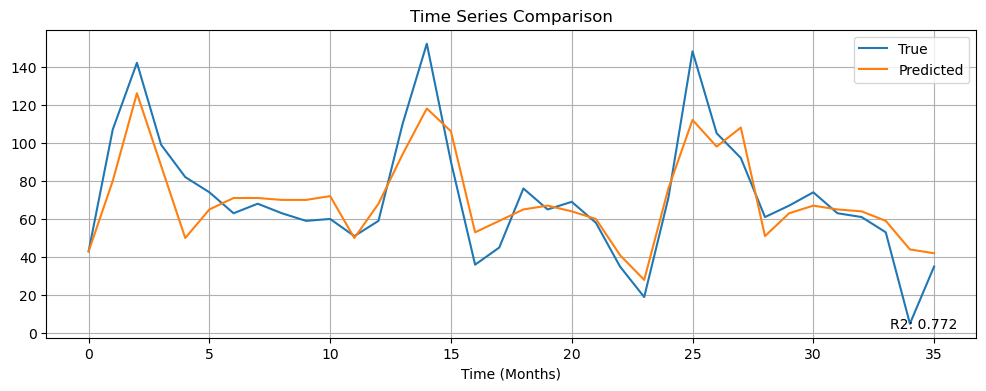

In [156]:
compute_metrics(preds_all, targets_all)